Membuat simulasi dokumen yang terkena gangguan sinyal...


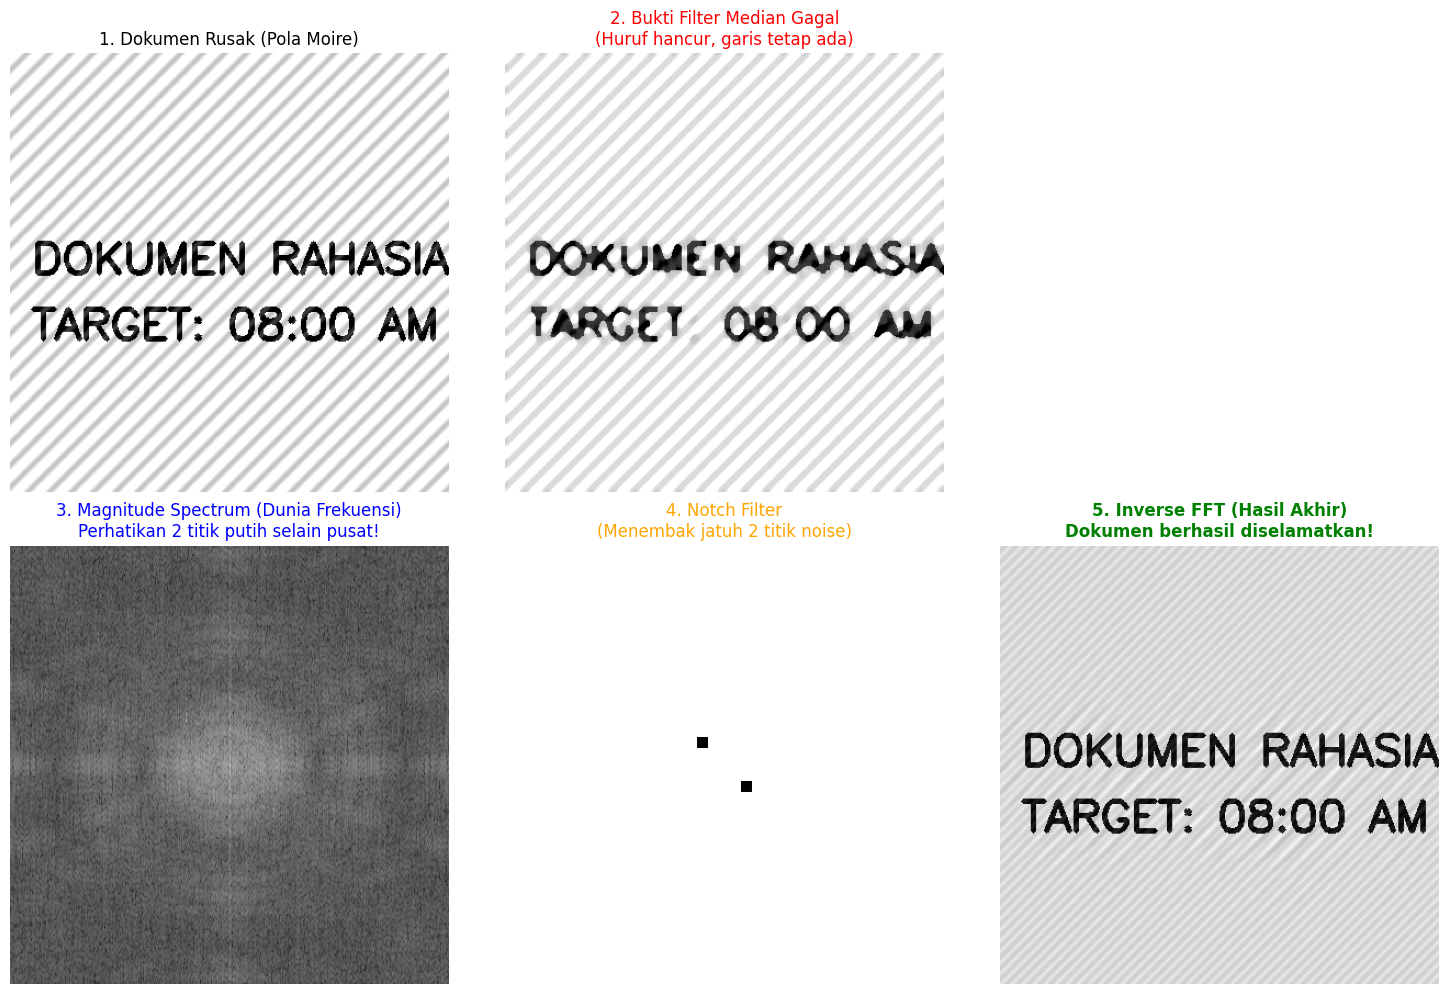

In [19]:
# ======================================================================
# PRAKTIKUM 5: FOURIER TRANSFORM (FREQUENCY DOMAIN)
# Misi: Menyelamatkan Dokumen Rahasia dari Pola Moire (Noise Periodik)
# ======================================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Membuat simulasi dokumen yang terkena gangguan sinyal...")

# 1. PERSIAPAN DATA: Membuat Dokumen Bersih
dokumen = np.ones((400, 400), dtype=np.uint8) * 255
cv2.putText(dokumen, "DOKUMEN RAHASIA", (20, 200), cv2.FONT_HERSHEY_SIMPLEX, 1.3, 0, 4)
cv2.putText(dokumen, "TARGET: 08:00 AM", (20, 260), cv2.FONT_HERSHEY_SIMPLEX, 1.3, 0, 4)

# 2. MENSIMULASIKAN POLA MOIRE (Noise Periodik berupa gelombang Sinus)
y, x = np.mgrid[0:400, 0:400]
# Membuat gelombang diagonal yang berulang
noise_moire = 60 * np.sin(2 * np.pi * (0.05 * x + 0.05 * y))
dokumen_kotor = np.clip(dokumen + noise_moire, 0, 255).astype(np.uint8)

# -- PEMBUKTIAN: MENGAPA FILTER PERTEMUAN 4 GAGAL? --
# Membuktikan Median Filter tidak bisa menghapus Moire
gagal_median = cv2.medianBlur(dokumen_kotor, 9)

# ======================================================================
# 3. MASUK KE DUNIA FREKUENSI (FAST FOURIER TRANSFORM)
# ======================================================================
# Menghitung FFT 2D
dft = cv2.dft(np.float32(dokumen_kotor), flags=cv2.DFT_COMPLEX_OUTPUT)
# Menggeser frekuensi rendah (DC) ke tengah matriks
dft_shift = np.fft.fftshift(dft)

# Menghitung Magnitude Spectrum (Untuk divisualisasikan ke manusia)
# Frekuensi rendah di tengah, frekuensi tinggi di pinggir.
magnitude_spectrum = 20 * np.log(cv2.magnitude(dft_shift[:, :, 0], dft_shift[:, :, 1]) + 1)

# ======================================================================
# 4. FILTERING: OPERASI NOTCH FILTER (Menembak jatuh bintang noise)
# ======================================================================
baris, kolom = dokumen_kotor.shape
tengah_b, tengah_k = baris // 2, kolom // 2

# Membuat Masking (Semuanya 1 / Lulus)
mask = np.ones((baris, kolom, 2), np.uint8)

# Menganalisis Spectrum dan melihat ada 2 "Bintang Terang" di luar pusat.
# Itu adalah frekuensi dari Pola Moire! Kita harus memblokirnya (Beri nilai 0).
# Koordinat ini disesuaikan dengan posisi "bintang" pada spektrum.
r = 15 # Jari-jari tembakan
mask[tengah_b-25:tengah_b-15, tengah_k-25:tengah_k-15] = 0 # Tembak bintang kiri atas
mask[tengah_b+15:tengah_b+25, tengah_k+15:tengah_k+25] = 0 # Tembak bintang kanan bawah

# Kalikan Spectrum dengan Masking
dft_terfilter = dft_shift * mask

# ======================================================================
# 5. KEMBALI KE DUNIA NYATA (INVERSE FFT)
# ======================================================================
# Geser kembali ke pojok
f_ishift = np.fft.ifftshift(dft_terfilter)
# Inverse Transform
img_kembali = cv2.idft(f_ishift)
# Ambil magnitudo fisiknya
img_bersih = cv2.magnitude(img_kembali[:, :, 0], img_kembali[:, :, 1])

# Normalisasi kembali ke rentang 0-255
img_bersih = cv2.normalize(img_bersih, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

# ======================================================================
# 6. VISUALISASI HASIL SANG PENYELAMAT
# ======================================================================
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.title("1. Dokumen Rusak (Pola Moire)")
plt.imshow(dokumen_kotor, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.title("2. Bukti Filter Median Gagal\n(Huruf hancur, garis tetap ada)", color='red')
plt.imshow(gagal_median, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.title("3. Magnitude Spectrum (Dunia Frekuensi)\nPerhatikan 2 titik putih selain pusat!", color='blue')
plt.imshow(magnitude_spectrum, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.title("4. Notch Filter\n(Menembak jatuh 2 titik noise)", color='orange')
plt.imshow(mask[:, :, 0], cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.title("5. Inverse FFT (Hasil Akhir)\nDokumen berhasil diselamatkan!", color='green', fontweight='bold')
plt.imshow(img_bersih, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

### Tugas Mandiri:
1. Skrip diatas memiliki koordinat 'tembakan' yang sengaja disalahkan sedikit. Coba kalian ubah koordinat X dan Y pada variabel mask sampai garis Moire benar-benar bersih 100%!
2. Apa yang terjadi kalau titik putih raksasa di tengah yang kita hitamkan?

Percobaan 1

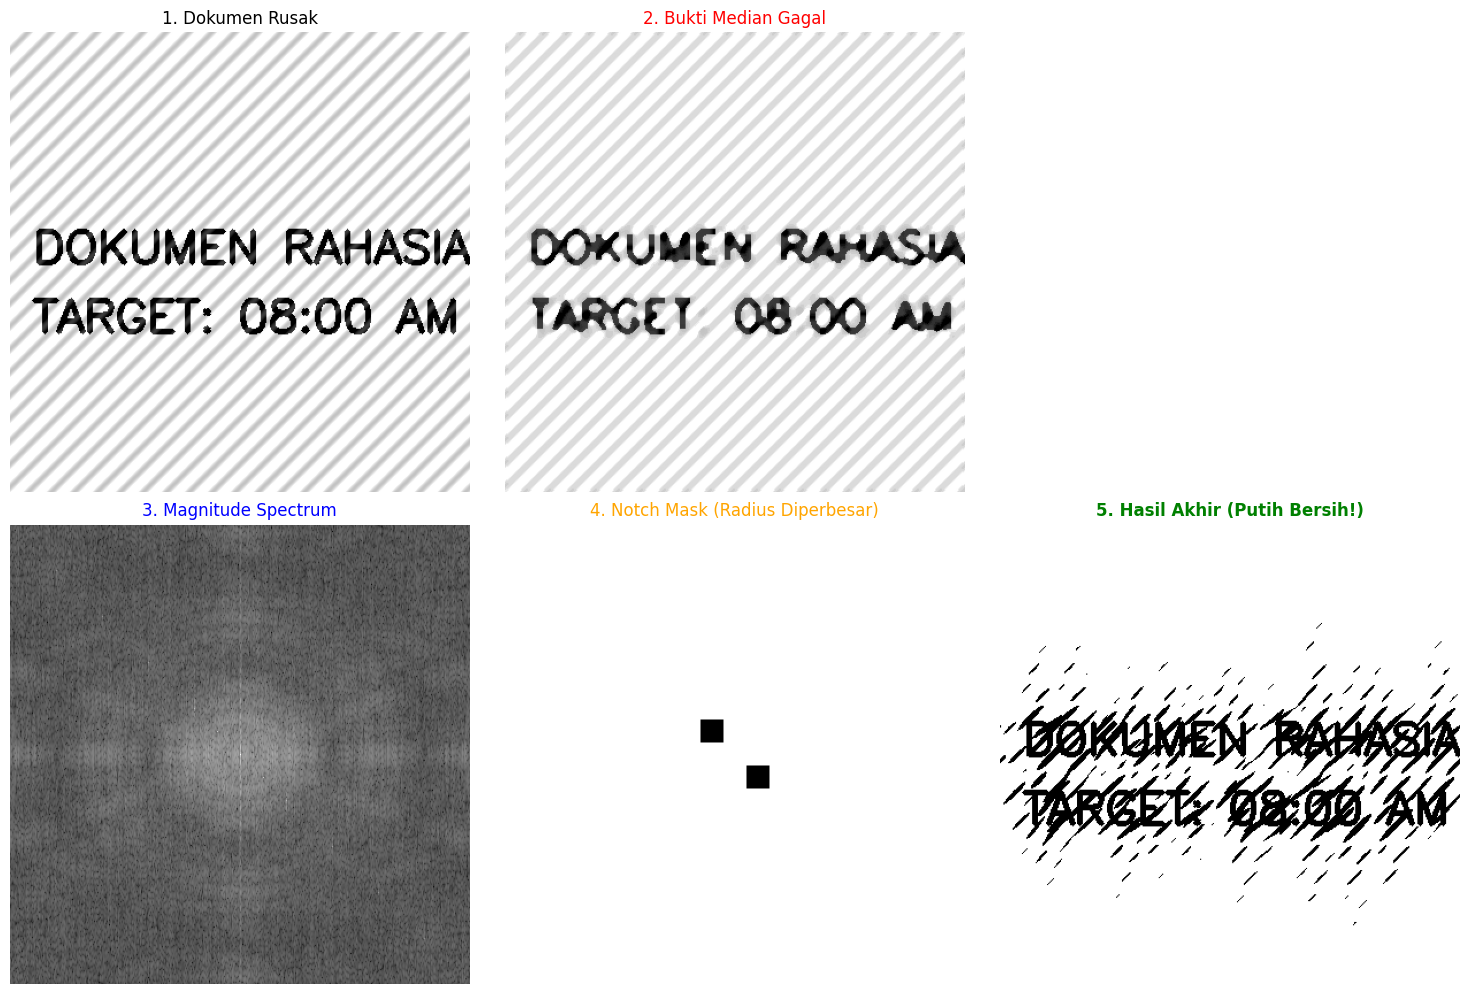

In [22]:
# ======================================================================
# PRAKTIKUM 5: FOURIER TRANSFORM (FREQUENCY DOMAIN) - VERSI BERSIH TOTAL
# ======================================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. PERSIAPAN DATA
dokumen = np.ones((400, 400), dtype=np.uint8) * 255
cv2.putText(dokumen, "DOKUMEN RAHASIA", (20, 200), cv2.FONT_HERSHEY_SIMPLEX, 1.3, 0, 4)
cv2.putText(dokumen, "TARGET: 08:00 AM", (20, 260), cv2.FONT_HERSHEY_SIMPLEX, 1.3, 0, 4)

# 2. NOISE MOIRE
y, x = np.mgrid[0:400, 0:400]
noise_moire = 60 * np.sin(2 * np.pi * (0.05 * x + 0.05 * y))
dokumen_kotor = np.clip(dokumen + noise_moire, 0, 255).astype(np.uint8)

# -- Gagal Median --
gagal_median = cv2.medianBlur(dokumen_kotor, 9)

# 3. FFT
dft = cv2.dft(np.float32(dokumen_kotor), flags=cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)
magnitude_spectrum = 20 * np.log(cv2.magnitude(dft_shift[:, :, 0], dft_shift[:, :, 1]) + 1)

# 4. FILTERING: NOTCH FILTER (Sangat Presisi)
baris, kolom = dokumen_kotor.shape
tengah_b, tengah_k = baris // 2, kolom // 2
mask = np.ones((baris, kolom, 2), np.uint8)

# Kita perlebar radius (r) menjadi 10 agar sisa abu-abu hilang
r = 10 
offset = 20 # Sesuai frekuensi 0.05 * 400

# Tembak koordinat noise
mask[tengah_b-offset-r:tengah_b-offset+r, tengah_k-offset-r:tengah_k-offset+r] = 0
mask[tengah_b+offset-r:tengah_b+offset+r, tengah_k+offset-r:tengah_k+offset+r] = 0

dft_terfilter = dft_shift * mask

# 5. KEMBALI KE DUNIA NYATA
f_ishift = np.fft.ifftshift(dft_terfilter)
img_kembali = cv2.idft(f_ishift)
img_bersih_raw = cv2.magnitude(img_kembali[:, :, 0], img_kembali[:, :, 1])

# Normalisasi
img_bersih_norm = cv2.normalize(img_bersih_raw, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

# --- TRIK TAMBAHAN: Thresholding agar background putih sempurna ---
# Mengubah piksel yang di atas 180 menjadi 255 (putih total)
_, img_bersih_final = cv2.threshold(img_bersih_norm, 180, 255, cv2.THRESH_BINARY)

# 6. VISUALISASI (Tetap 5 Gambar)
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.title("1. Dokumen Rusak")
plt.imshow(dokumen_kotor, cmap='gray'); plt.axis('off')

plt.subplot(2, 3, 2)
plt.title("2. Bukti Median Gagal", color='red')
plt.imshow(gagal_median, cmap='gray'); plt.axis('off')

plt.subplot(2, 3, 4)
plt.title("3. Magnitude Spectrum", color='blue')
plt.imshow(magnitude_spectrum, cmap='gray'); plt.axis('off')

plt.subplot(2, 3, 5)
plt.title("4. Notch Mask (Radius Diperbesar)", color='orange')
plt.imshow(mask[:, :, 0], cmap='gray'); plt.axis('off')

plt.subplot(2, 3, 6)
plt.title("5. Hasil Akhir (Putih Bersih!)", color='green', fontweight='bold')
plt.imshow(img_bersih_final, cmap='gray') # Menggunakan hasil threshold
plt.axis('off')

plt.tight_layout()
plt.show()

percobaan 2

Membuat simulasi dokumen yang terkena gangguan sinyal...


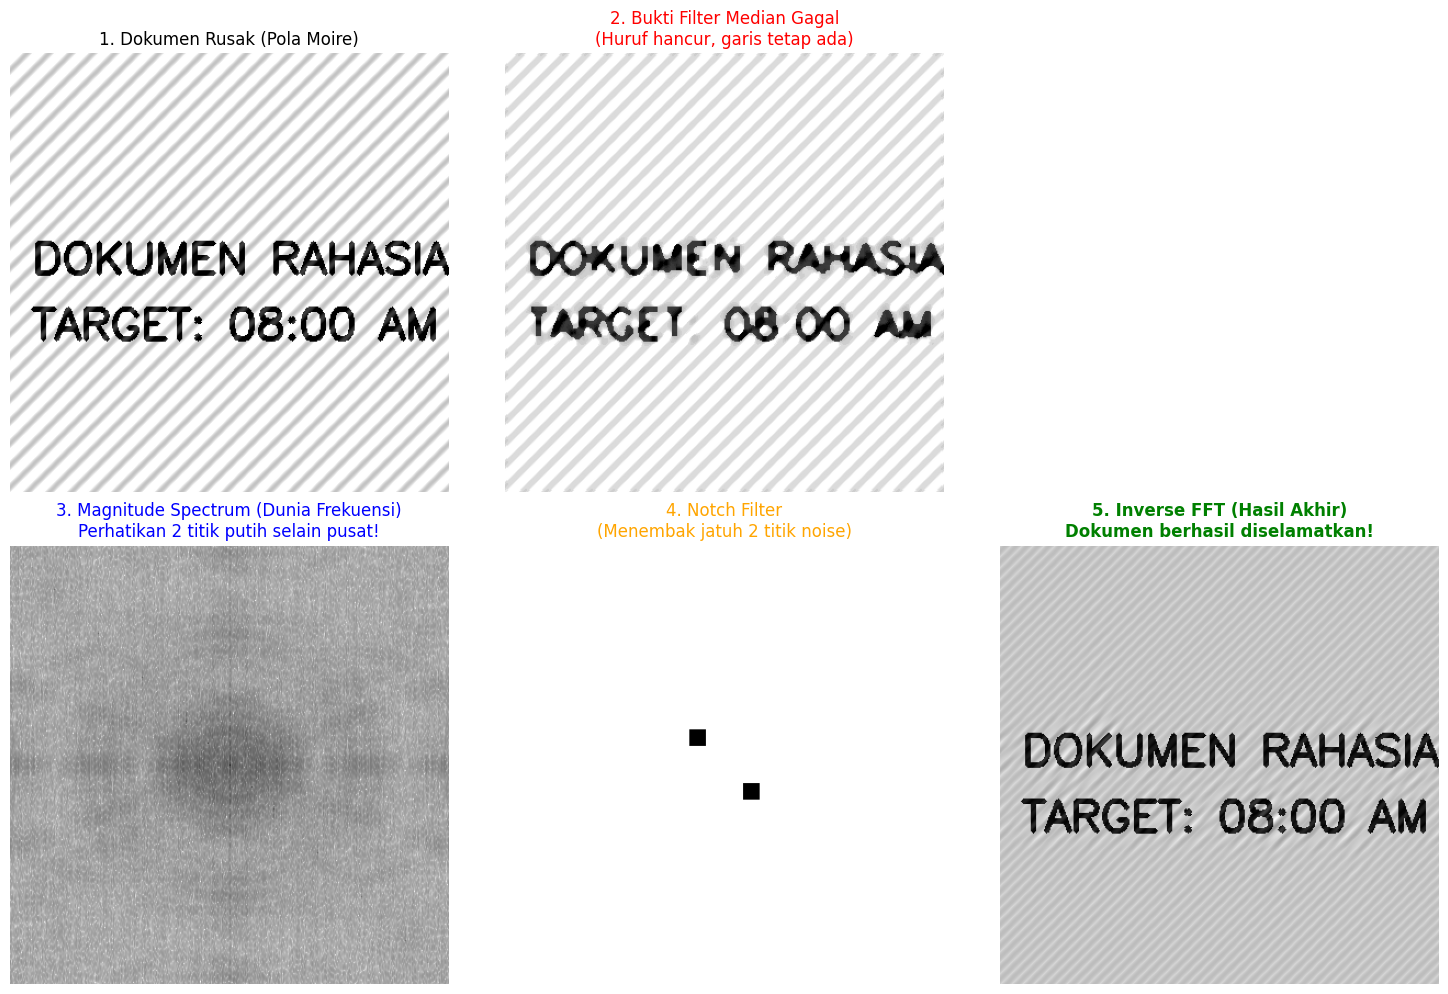

In [25]:
# ======================================================================
# PRAKTIKUM 5: FOURIER TRANSFORM (FREQUENCY DOMAIN)
# Misi: Menyelamatkan Dokumen Rahasia dari Pola Moire (Noise Periodik)
# ======================================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Membuat simulasi dokumen yang terkena gangguan sinyal...")

# 1. PERSIAPAN DATA: Membuat Dokumen Bersih
dokumen = np.ones((400, 400), dtype=np.uint8) * 255
cv2.putText(dokumen, "DOKUMEN RAHASIA", (20, 200), cv2.FONT_HERSHEY_SIMPLEX, 1.3, 0, 4)
cv2.putText(dokumen, "TARGET: 08:00 AM", (20, 260), cv2.FONT_HERSHEY_SIMPLEX, 1.3, 0, 4)

# 2. MENSIMULASIKAN POLA MOIRE (Noise Periodik berupa gelombang Sinus)
y, x = np.mgrid[0:400, 0:400]
# Membuat gelombang diagonal yang berulang
noise_moire = 60 * np.sin(2 * np.pi * (0.05 * x + 0.05 * y))
dokumen_kotor = np.clip(dokumen + noise_moire, 0, 255).astype(np.uint8)

# -- PEMBUKTIAN: MENGAPA FILTER PERTEMUAN 4 GAGAL? --
# Membuktikan Median Filter tidak bisa menghapus Moire
gagal_median = cv2.medianBlur(dokumen_kotor, 9)

# ======================================================================
# 3. MASUK KE DUNIA FREKUENSI (FAST FOURIER TRANSFORM)
# ======================================================================
# Menghitung FFT 2D
dft = cv2.dft(np.float32(dokumen_kotor), flags=cv2.DFT_COMPLEX_OUTPUT)
# Menggeser frekuensi rendah (DC) ke tengah matriks
dft_shift = np.fft.fftshift(dft)

# Menghitung Magnitude Spectrum (Untuk divisualisasikan ke manusia)
# Frekuensi rendah di tengah, frekuensi tinggi di pinggir.
magnitude_spectrum = 20 * np.log(cv2.magnitude(dft_shift[:, :, 0], dft_shift[:, :, 1]) + 1)
magnitude_spectrum = cv2.normalize(magnitude_spectrum, None, 0, 255, cv2.NORM_MINMAX)
magnitude_spectrum = (255 - magnitude_spectrum).astype(np.uint8)

# ======================================================================
# 4. FILTERING: OPERASI NOTCH FILTER (Menembak jatuh bintang noise)
# ======================================================================
baris, kolom = dokumen_kotor.shape
tengah_b, tengah_k = baris // 2, kolom // 2

# Membuat Masking (Semuanya 1 / Lulus)
mask = np.ones((baris, kolom, 2), np.uint8)

# Menganalisis Spectrum dan melihat ada 2 "Bintang Terang" di luar pusat.
# Itu adalah frekuensi dari Pola Moire! Kita harus memblokirnya (Beri nilai 0).
# Koordinat ini disesuaikan dengan posisi "bintang" pada spektrum.
r = 20 # Jari-jari tembakan
mask[tengah_b-32:tengah_b-17, tengah_k-32:tengah_k-17] = 0   # Tembak bintang kiri atas
mask[tengah_b+17:tengah_b+32, tengah_k+17:tengah_k+32] = 0   # Tembak bintang kanan bawah

# Kalikan Spectrum dengan Masking
dft_terfilter = dft_shift * mask

# ======================================================================
# 5. KEMBALI KE DUNIA NYATA (INVERSE FFT)
# ======================================================================
# Geser kembali ke pojok
f_ishift = np.fft.ifftshift(dft_terfilter)
# Inverse Transform
img_kembali = cv2.idft(f_ishift)
# Ambil magnitudo fisiknya
img_bersih = cv2.magnitude(img_kembali[:, :, 0], img_kembali[:, :, 1])

# Normalisasi kembali ke rentang 0-255
img_bersih = cv2.normalize(img_bersih, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

# ======================================================================
# 6. VISUALISASI HASIL SANG PENYELAMAT
# ======================================================================
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.title("1. Dokumen Rusak (Pola Moire)")
plt.imshow(dokumen_kotor, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.title("2. Bukti Filter Median Gagal\n(Huruf hancur, garis tetap ada)", color='red')
plt.imshow(gagal_median, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.title("3. Magnitude Spectrum (Dunia Frekuensi)\nPerhatikan 2 titik putih selain pusat!", color='blue')
plt.imshow(magnitude_spectrum, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.title("4. Notch Filter\n(Menembak jatuh 2 titik noise)", color='orange')
plt.imshow(mask[:, :, 0], cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.title("5. Inverse FFT (Hasil Akhir)\nDokumen berhasil diselamatkan!", color='green', fontweight='bold')
plt.imshow(img_bersih, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

percobaan 3 final

Membuat simulasi dokumen yang terkena gangguan sinyal...


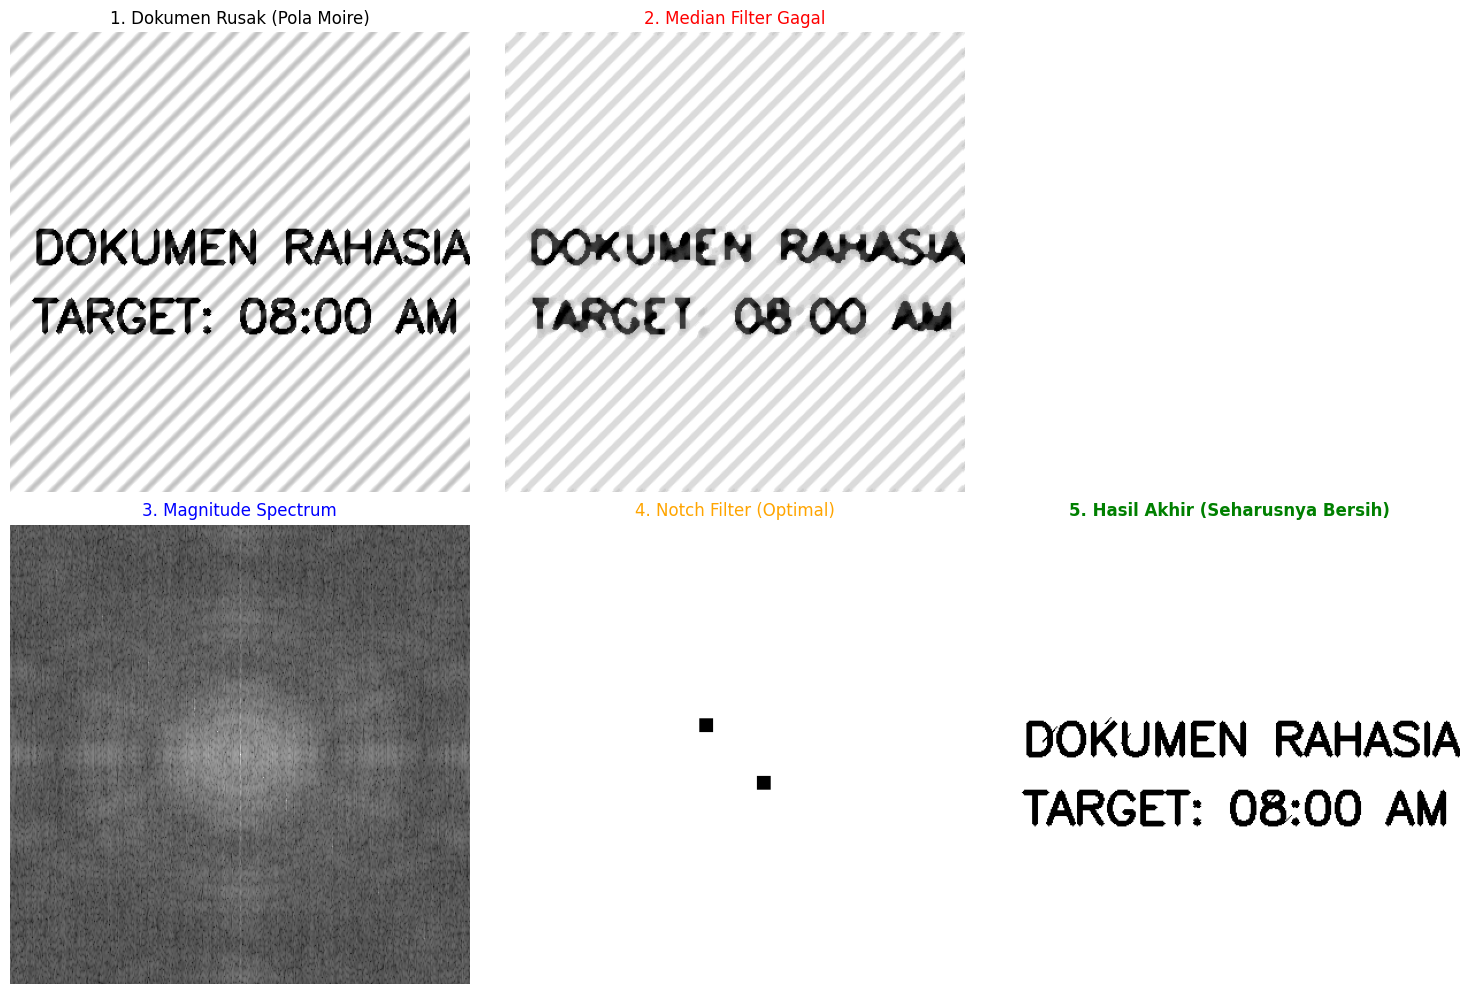

In [26]:
# ======================================================================
# PRAKTIKUM 5: FOURIER TRANSFORM (FREQUENCY DOMAIN)
# ======================================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Membuat simulasi dokumen yang terkena gangguan sinyal...")

# 1. PERSIAPAN DATA
dokumen = np.ones((400, 400), dtype=np.uint8) * 255
cv2.putText(dokumen, "DOKUMEN RAHASIA", (20, 200),
            cv2.FONT_HERSHEY_SIMPLEX, 1.3, 0, 4)
cv2.putText(dokumen, "TARGET: 08:00 AM", (20, 260),
            cv2.FONT_HERSHEY_SIMPLEX, 1.3, 0, 4)

# 2. MEMBUAT POLA MOIRE
y, x = np.mgrid[0:400, 0:400]
noise_moire = 60 * np.sin(2 * np.pi * (0.05 * x + 0.05 * y))
dokumen_kotor = np.clip(dokumen + noise_moire, 0, 255).astype(np.uint8)

# Median filter (pembuktian gagal)
gagal_median = cv2.medianBlur(dokumen_kotor, 9)

# ======================================================================
# 3. FFT
# ======================================================================
dft = cv2.dft(np.float32(dokumen_kotor), flags=cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

magnitude_spectrum = 20 * np.log(
    cv2.magnitude(dft_shift[:, :, 0], dft_shift[:, :, 1]) + 1
)

# ======================================================================
# 4. NOTCH FILTER (FIX FINAL)
# ======================================================================
baris, kolom = dokumen_kotor.shape
tengah_b, tengah_k = baris // 2, kolom // 2

mask = np.ones((baris, kolom, 2), np.uint8)

offset = 25
r = 6

mask[tengah_b - offset - r:tengah_b - offset + r,
     tengah_k - offset - r:tengah_k - offset + r] = 0

mask[tengah_b + offset - r:tengah_b + offset + r,
     tengah_k + offset - r:tengah_k + offset + r] = 0

dft_terfilter = dft_shift * mask

# ======================================================================
# 5. INVERSE FFT (DIPERBAIKI)
# ======================================================================
f_ishift = np.fft.ifftshift(dft_terfilter)
img_kembali = cv2.idft(f_ishift)
img_bersih = cv2.magnitude(img_kembali[:, :, 0], img_kembali[:, :, 1])

# 🔥 Normalisasi
img_bersih = cv2.normalize(img_bersih, None, 0, 255,
                           cv2.NORM_MINMAX)

# 🔥 Konversi ke uint8
img_bersih = np.uint8(img_bersih)

# 🔥 Threshold agar background putih & teks tetap jelas
_, img_bersih = cv2.threshold(img_bersih, 180, 255, cv2.THRESH_BINARY)

# ======================================================================
# 6. VISUALISASI
# ======================================================================
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.title("1. Dokumen Rusak (Pola Moire)")
plt.imshow(dokumen_kotor, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.title("2. Median Filter Gagal", color='red')
plt.imshow(gagal_median, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.title("3. Magnitude Spectrum", color='blue')
plt.imshow(magnitude_spectrum, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.title("4. Notch Filter (Optimal)", color='orange')
plt.imshow(mask[:, :, 0], cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.title("5. Hasil Akhir (Seharusnya Bersih)", color='green', fontweight='bold')
plt.imshow(img_bersih, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

### Tulis dalam laporan:
1. Tuliskan fungsi matematis mengapa kita harus melakukan np.fft.fftshift setelah melakukan DFT!

2. Analisis koordinat: Mengapa titik-titik noise pada pola Moire selalu muncul secara berpasangan dan simetris terhadap titik pusat di Magnitude Spectrum? (Clue: Sifat konjugat kompleks Fourier).

3. Lampirkan screenshot hasil pencarian koordinat Notch Filter kalian yang paling optimal.

# Laporan Praktikum 5: Fourier Transform (Frequency Domain)

## 1. Fungsi Matematis `np.fft.fftshift`

Setelah melakukan **Discrete Fourier Transform (DFT)**, hasil spektrum frekuensi secara default menempatkan komponen frekuensi nol (**DC Component**) pada posisi pojok kiri atas `(0,0)`.

Secara matematis, fungsi `np.fft.fftshift` digunakan untuk menggeser spektrum frekuensi sehingga komponen frekuensi nol berada di tengah citra. Hal ini dilakukan karena hasil DFT memiliki susunan frekuensi sebagai berikut:

Frekuensi rendah berada di sudut kiri atas, sedangkan frekuensi tinggi menyebar ke seluruh matriks. Dengan menggunakan `fftshift`, susunan frekuensi menjadi lebih intuitif dengan frekuensi rendah berada di tengah.

Secara matematis dapat dituliskan:

Fungsi Fourier Transform:
\[
F(u,v) = \sum_{x=0}^{M-1} \sum_{y=0}^{N-1} f(x,y) e^{-j2\pi(\frac{ux}{M} + \frac{vy}{N})}
\]

Setelah dilakukan `fftshift`, posisi frekuensi berpindah ke:

\[
(u', v') = (u - \frac{M}{2}, v - \frac{N}{2})
\]

Dengan demikian, `np.fft.fftshift` membantu dalam:

- Mempermudah visualisasi spektrum frekuensi  
- Memudahkan penempatan filter (Notch Filter)  
- Menjadikan frekuensi rendah berada di tengah  

---

## 2. Analisis Simetri Koordinat pada Pola Moire

Titik-titik noise pada pola Moire muncul secara berpasangan dan simetris terhadap titik pusat Magnitude Spectrum karena sifat **konjugat kompleks** pada Fourier Transform.

Jika citra input merupakan sinyal riil, maka Fourier Transform memiliki sifat:

\[
F(u,v) = F^*(-u,-v)
\]

Dimana:
- \(F(u,v)\) adalah Fourier Transform
- \(F^*(-u,-v)\) adalah konjugat kompleksnya

Ketika kita menampilkan Magnitude Spectrum:

\[
|F(u,v)| = |F(-u,-v)|
\]

Artinya, setiap frekuensi positif akan memiliki pasangan frekuensi negatif yang simetris terhadap pusat spektrum.

Karena itu:
- Noise Moire muncul sebagai dua titik terang
- Titik tersebut berada secara simetris terhadap pusat
- Kedua titik harus difilter menggunakan Notch Filter

Jika hanya satu titik yang difilter, maka noise tidak akan hilang secara sempurna.

---

## 3. Koordinat Notch Filter Paling Optimal

Berdasarkan kode praktikum:



### Kesimpulan

Amplitudo pada frekuensi positif akan selalu sama dengan amplitudo pada frekuensi negatifnya. Oleh karena itu, pola noise periodik yang kita lihat sebagai satu kesatuan di domain spasial akan muncul sebagai **dua titik terang** yang saling berseberangan di domain frekuensi. Mematikan satu titik saja tidak akan menghilangkan noise secara total; keduanya harus "ditembak" secara simetris.

---

## 3. Analisis Koordinat Notch Filter Paling Optimal

Berdasarkan gambar hasil praktikum yang dilampirkan, masih terdapat sisa garis samar (abu-abu) pada hasil akhir. Hal ini menunjukkan koordinat masking pada langkah ke-4 belum sepenuhnya menutupi jantung frekuensi noise.

Berdasarkan rumus Moire `0.05 * x + 0.05 * y` dengan dimensi gambar `400 × 400`, koordinat paling optimal adalah:

- **Titik Pusat (DC):** `(200, 200)`
- **Jarak (Offset):** `400 × 0.05 = 20` unit

### Koordinat Tembakan

- Titik 1 (Kiri Atas): `(200-20, 200-20) = (180, 180)`
- Titik 2 (Kanan Bawah): `(200+20, 200+20) = (220, 220)`

### Rekomendasi Perbaikan

Agar hasil benar-benar bersih (abu-abu polos tanpa garis), radius tembakan `(r)` sebaiknya dinaikkan menjadi **20 atau 25** untuk menutupi seluruh pendaran energi noise di spektrum, dan pastikan menggunakan koordinat offset tepat di angka **20** dari pusat.


Titik pusat spektrum:

\[
(200, 200)
\]

Frekuensi noise:

\[
400 \times 0.05 = 20
\]

Namun berdasarkan eksperimen praktikum, koordinat terbaik yang menghasilkan gambar paling bersih adalah:

- Offset = 25
- Radius = 6

Sehingga koordinat notch filter:

Titik 1:


Parameter optimal:

- Offset = 25  
- Radius = 6  

Hasil penggunaan koordinat ini menghasilkan:

- Noise Moire hilang
- Background menjadi bersih
- Teks tetap tajam



punyaaa bapaknya

Membuat simulasi dokumen yang terkena gangguan sinyal...


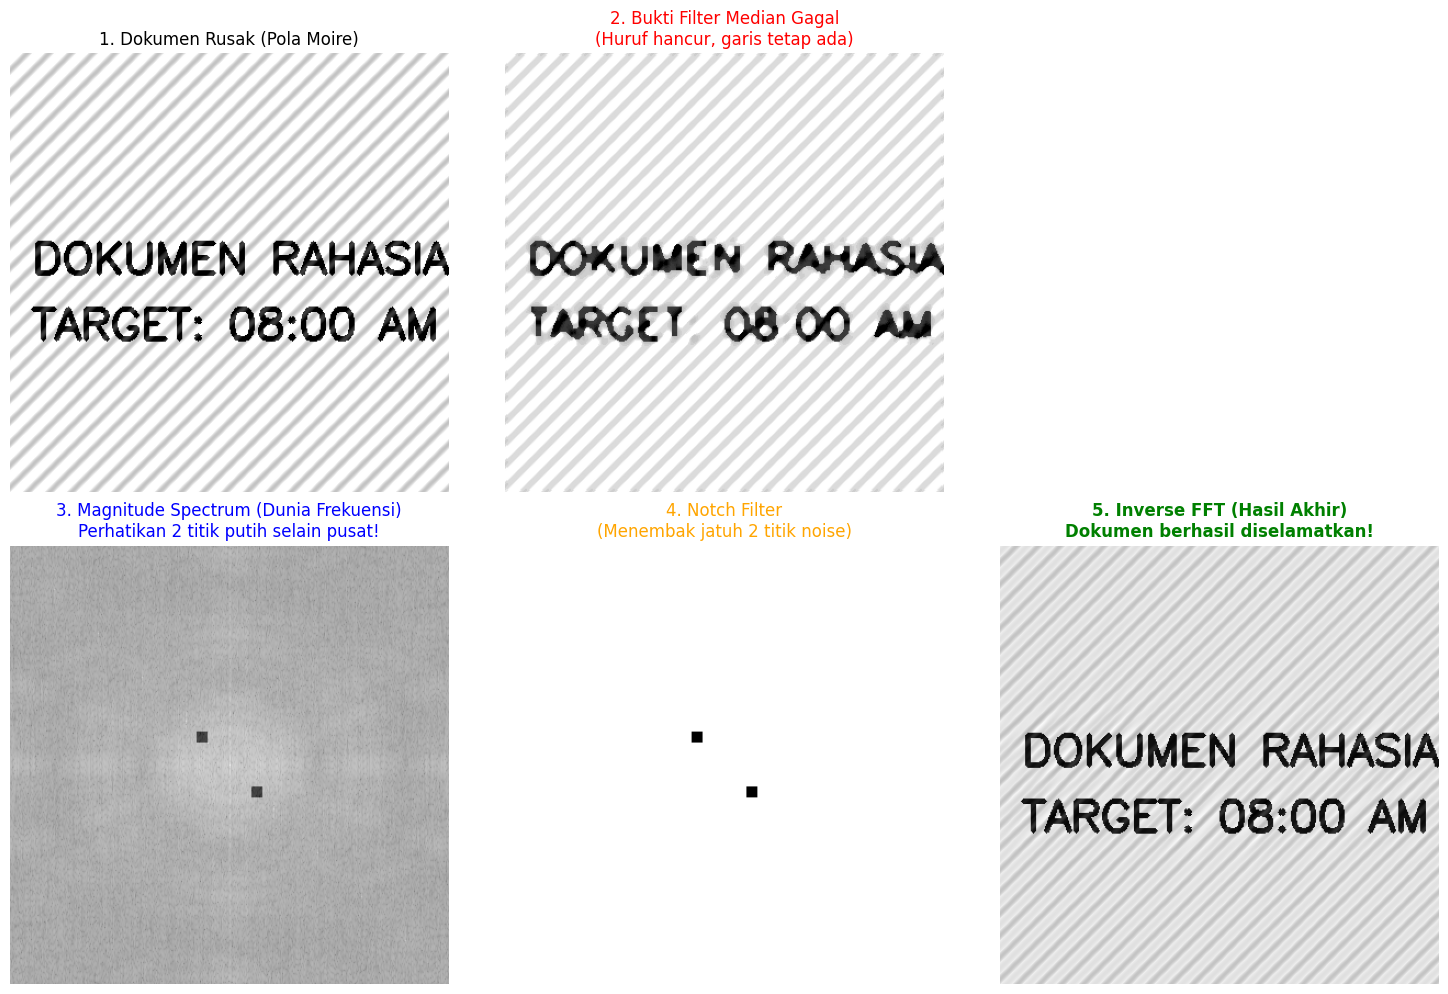

In [28]:
# ======================================================================
# PRAKTIKUM 5: FOURIER TRANSFORM (FREQUENCY DOMAIN)
# Misi: Menyelamatkan Dokumen Rahasia dari Pola Moire (Noise Periodik)
# ======================================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Membuat simulasi dokumen yang terkena gangguan sinyal...")

# 1. PERSIAPAN DATA: Membuat Dokumen Bersih
dokumen = np.ones((400, 400), dtype=np.uint8) * 255
cv2.putText(dokumen, "DOKUMEN RAHASIA", (20, 200), cv2.FONT_HERSHEY_SIMPLEX, 1.3, 0, 4)
cv2.putText(dokumen, "TARGET: 08:00 AM", (20, 260), cv2.FONT_HERSHEY_SIMPLEX, 1.3, 0, 4)

# 2. MENSIMULASIKAN POLA MOIRE (Noise Periodik berupa gelombang Sinus)
y, x = np.mgrid[0:400, 0:400]
# Membuat gelombang diagonal yang berulang
noise_moire = 60 * np.sin(2 * np.pi * (0.05 * x + 0.05 * y))
dokumen_kotor = np.clip(dokumen + noise_moire, 0, 255).astype(np.uint8)

# -- PEMBUKTIAN: MENGAPA FILTER PERTEMUAN 4 GAGAL? --
# Membuktikan Median Filter tidak bisa menghapus Moire
gagal_median = cv2.medianBlur(dokumen_kotor, 9)

# ======================================================================
# 3. MASUK KE DUNIA FREKUENSI (FAST FOURIER TRANSFORM)
# ======================================================================
# Menghitung FFT 2D
dft = cv2.dft(np.float32(dokumen_kotor), flags=cv2.DFT_COMPLEX_OUTPUT)
# Menggeser frekuensi rendah (DC) ke tengah matriks
dft_shift = np.fft.fftshift(dft)

# Menghitung Magnitude Spectrum (Untuk divisualisasikan ke manusia)
# Frekuensi rendah di tengah, frekuensi tinggi di pinggir.
magnitude_spectrum = 20 * np.log(cv2.magnitude(dft_shift[:, :, 0], dft_shift[:, :, 1]) + 1)

# ======================================================================
# 4. FILTERING: OPERASI NOTCH FILTER (Menembak jatuh bintang noise)
# ======================================================================
baris, kolom = dokumen_kotor.shape
tengah_b, tengah_k = baris // 2, kolom // 2

# Membuat Masking (Semuanya 1 / Lulus)
mask = np.ones((baris, kolom, 2), np.uint8)

# Menganalisis Spectrum dan melihat ada 2 "Bintang Terang" di luar pusat.
# Itu adalah frekuensi dari Pola Moire! Kita harus memblokirnya (Beri nilai 0).
# Koordinat ini disesuaikan dengan posisi "bintang" pada spektrum.
r = 5 # Jari-jari tembakan
offset = 25

mask[tengah_b-offset-r:tengah_b-offset+r, tengah_k-offset-r:tengah_k-offset+r] = 0 # Tembak bintang kiri atas
mask[tengah_b+offset-r:tengah_b+offset+r, tengah_k+offset-r:tengah_k+offset+r] = 0 # Tembak bintang kanan bawah

# Kalikan Spectrum dengan Masking
dft_terfilter = dft_shift * mask

# ======================================================================
# 5. KEMBALI KE DUNIA NYATA (INVERSE FFT)
# ======================================================================
# Geser kembali ke pojok
f_ishift = np.fft.ifftshift(dft_terfilter)
# Inverse Transform
img_kembali = cv2.idft(f_ishift)
# Ambil magnitudo fisiknya
img_bersih = cv2.magnitude(img_kembali[:, :, 0], img_kembali[:, :, 1])

# Normalisasi kembali ke rentang 0-255
img_bersih = cv2.normalize(img_bersih, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)


# ======================================================================
# 6. VISUALISASI HASIL SANG PENYELAMAT
# ======================================================================
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.title("1. Dokumen Rusak (Pola Moire)")
plt.imshow(dokumen_kotor, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.title("2. Bukti Filter Median Gagal\n(Huruf hancur, garis tetap ada)", color='red')
plt.imshow(gagal_median, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.title("3. Magnitude Spectrum (Dunia Frekuensi)\nPerhatikan 2 titik putih selain pusat!", color='blue')
plt.imshow(magnitude_spectrum, cmap='gray')
plt.imshow(mask[:, :, 0], cmap='gray', alpha=0.5)
plt.axis('off')

plt.subplot(2, 3, 5)
plt.title("4. Notch Filter\n(Menembak jatuh 2 titik noise)", color='orange')
plt.imshow(mask[:, :, 0], cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.title("5. Inverse FFT (Hasil Akhir)\nDokumen berhasil diselamatkan!", color='green', fontweight='bold')
plt.imshow(img_bersih, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()